In [1]:
# !pip install requests pandas yfinance numpy cloudscraper xlrd lxml html5lib playwright openpyxl html5lib matplotlib

import os
import sys
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from dateutil.relativedelta import relativedelta
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
from datetime import datetime


warnings.filterwarnings('ignore', category=UserWarning)

sys.version_info
# !python --version
# print("當前 Kernel 使用的版本:", sys.version.split()[0])
# print("當前 Kernel 引用的執行檔路徑:", sys.executable)
# !jupyter kernelspec list
# !pip install finlab


sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)

In [12]:
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
# 1. 查詢機制：爬取加權指數與紅藍燈訊號
# ==========================================

def fetch_data_robust(start_year=2003, file_path='ndc.xls', target ='0050.TW'):
# ==========================================
    now = datetime.now()
    url = f"https://index.ndc.gov.tw/n/excel/data/eco/indicators?sy={start_year}&sm=1&ey={now.year}&em={now.month}&id=2%2C12&sq=0,0,0&file_type=xls"
    
    ndc_df = None

    # 第一階段：檢查並偵錯讀取本地檔案
    if os.path.exists(file_path):
        print(f"🔍 進入 Debug 模式：讀取本地檔案 '{file_path}'...")
        try:
            # 1. 使用您指定的 debug_read 方式：xlrd 引擎且不設表頭
            raw_data = pd.read_excel(file_path, engine='xlrd', header=None)
            
            print("📊 [Debug] 原始資料前 15 列預覽：")
            print(raw_data.head(15))
            
            # 2. 根據截圖邏輯提取：跳過前 2 列，取第 0 欄與第 2 欄
            ndc_df = raw_data.iloc[2:, [0, 2]].copy()
            ndc_df.columns = ['Date', 'Score']
            print("✅ 本地 Excel 解析成功！")
            
        except Exception as e:
            print(f"⚠️ xlrd 讀取失敗（報錯：{e}），嘗試切換至 HTML 解析模式...")
            # 備援：多重編碼解析 (處理假 XLS)
            for enc in ['cp950', 'utf-8', 'utf-16']:
                try:
                    tables = pd.read_html(file_path, encoding=enc)
                    raw_html_df = tables[0]
                    ndc_df = raw_html_df.iloc[2:, [0, 2]].copy()
                    ndc_df.columns = ['Date', 'Score']
                    print(f"✅ 使用 HTML 編碼 '{enc}' 解析成功！")
                    break
                except:
                    continue

    # 第二階段：若無檔案或解析失敗，嘗試自動抓取
    if ndc_df is None:
        print(f"🌐 嘗試自動從國發會網頁抓取數據...")
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            
            # 先存檔，方便下次 debug
            with open(file_path, 'wb') as f:
                f.write(res.content)
            print(f"✅ 下載存檔成功：{file_path}，請重新執行程式以進入 Debug 解析。")
            return None
                
        except Exception as e:
            # 第三階段：抓取失敗，顯示手動下載提示
            print(f"❌ 自動抓取失敗: {e}")
            print("\n" + "="*50)
            print("🚨 【請手動下載資料】 🚨")
            print('請用瀏覽器下載下方網址，命名為 {file_path} 放入目錄：')
            print(f"\n{url}\n")
            print("="*50 + "\n")
            return None

    # --- 後續資料清洗與 0050 合併 ---
    # 清洗掉非日期或非分數的雜質
    ndc_df = ndc_df.dropna(subset=['Date', 'Score'])
    ndc_df['Date'] = pd.to_datetime(ndc_df['Date'], errors='coerce')
    ndc_df = ndc_df.dropna(subset=['Date'])
    ndc_df.set_index('Date', inplace=True)
    ndc_df['Score'] = pd.to_numeric(ndc_df['Score'], errors='coerce')

    # 燈號判定
    conditions = [(ndc_df['Score'] >= 38), (ndc_df['Score'] <= 16)]
    ndc_df['Light'] = np.select(conditions, ['紅', '藍'], default='其他')

    # 抓取 0050
    print(f'正在獲取 {target} 歷史報價並合併資料...')
    etf = yf.Ticker(target).history(start=f"{start_year}-01-01", period="max", interval="1mo")
    etf.index = etf.index.tz_localize(None).to_period('M').to_timestamp()
    
    return etf[['Close']].join(ndc_df[['Score', 'Light']], how='left').dropna(subset=['Score'])

    
    
# ==========================================
# 2. 策略函式：輸入資料並產出買賣訊號
# ==========================================
def generate_signals(df):
    """
    注意事項：股市領先基本面，且國發會 T 月的燈號在 T+1 月底才公布。
    為了避免「未來函數(Look-ahead bias)」，我們將燈號訊號向後平移 1 個月。
    亦即：T+1 月底的收盤價，對應的是 T 月的燈號決策。
    """
    strategy_df = df.copy()
    # 訊號遞延 1 個月生效 (符合現實公布時間)
    strategy_df['Signal_Light'] = strategy_df['Light'].shift(1)
    
    # 動作定義：確知上個月藍燈 -> 買進(1)；確知上個月紅燈 -> 賣出(-1)；其他 -> 觀望(0)
    strategy_df['Action'] = 0
    strategy_df.loc[strategy_df['Signal_Light'] == '藍', 'Action'] = 1
    strategy_df.loc[strategy_df['Signal_Light'] == '紅', 'Action'] = -1
    
    return strategy_df

# ==========================================
# 3. 驗證函式：回測並計算自訂月份的平均獲利
# ==========================================
def backtest_strategy(strategy_df, hold_months=6):
    results = []
    # 篩選出所有觸發「買進」的時間點
    buy_dates = strategy_df[strategy_df['Action'] == 1].index
    
    for buy_date in buy_dates:
        # 計算預計賣出的月份
        sell_date = buy_date + relativedelta(months=hold_months)
        
        # 確保回測資料涵蓋到預計賣出的時間
        if sell_date in strategy_df.index:
            buy_price = strategy_df.loc[buy_date, 'Close']
            sell_price = strategy_df.loc[sell_date, 'Close']
            ret_pct = (sell_price - buy_price) / buy_price * 100
            
            results.append({
                '買進月': buy_date.strftime('%Y/%m'),
                '賣出月': sell_date.strftime('%Y/%m'),
                '獲利%': ret_pct
            })
            
    if not results:
        print("查無符合條件或已走完回測時間的交易紀錄。")
        return 0

    res_df = pd.DataFrame(results)
    avg_return = res_df['獲利%'].mean()
    win_rate = (res_df['獲利%'] > 0).mean() * 100
    
    print(f"=== 藍燈買進策略回測 (固定持有 {hold_months} 個月) ===")
    print(f"總交易筆數 : {len(results)} 筆")
    print(f"平均獲利   : {avg_return:.2f}%")
    print(f"交易勝率   : {win_rate:.1f}%")
    print("==================================================")
    
    return avg_return

# ==========================================
# 3. 驗證函式 (進階統計版：新增平均盈虧與總盈虧)
# ==========================================
def backtest_advanced(strategy_df, hold_months=6):
    buy_results = []
    sell_results = []
    
    for current_date in strategy_df.index:
        action = strategy_df.loc[current_date, 'Action']
        if action == 0:
            continue
            
        future_date = current_date + relativedelta(months=hold_months)
        
        if future_date in strategy_df.index:
            current_price = strategy_df.loc[current_date, 'Close']
            future_price = strategy_df.loc[future_date, 'Close']
            ret_pct = (future_price - current_price) / current_price * 100
            
            if action == 1:
                buy_results.append(ret_pct)
            elif action == -1:
                sell_results.append(ret_pct)
                
    # 統計輸出模組
    def print_stats(results, signal_name):
        if not results:
            return f"{signal_name}訊號: 無足夠歷史資料"
            
        res_arr = np.array(results)
        wins = res_arr[res_arr > 0]
        losses = res_arr[res_arr <= 0]
        
        # 計算各項進階核心指標
        win_rate = (len(wins) / len(res_arr)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = np.mean(losses) if len(losses) > 0 else 0
        avg_pnl = np.mean(res_arr)   # 投資真正關心的期望值
        total_pnl = np.sum(res_arr)  # 持續執行的總績效
        
        return (f"[{signal_name}]\n"
                f"樣本總數 : {len(res_arr):>5} 筆\n"
                f"交易勝率 : {win_rate:>6.1f} %\n"
                f"平均獲利 : {avg_win:>6.2f} %\n"
                f"平均虧損 : {avg_loss:>6.2f} %\n"
                f"平均盈虧 : {avg_pnl:>6.2f} %  <-- 策略期望值\n"
                f"總累積盈虧: {total_pnl:>6.2f} %  <-- 長期執行總合")

    print(f"\n=== 訊號出現後持有 {hold_months} 個月之進階統計 ===")
    print(print_stats(buy_results, "買訊 (上月藍燈)"))
    print("-" * 40)
    print(print_stats(sell_results, "賣訊 (上月紅燈)"))
    print("==================================================")

def run_custom_strategy(df, config, monthly_budget=10000):
    """
    更新邏輯：
    1. allocation: [股票比, 現金比] 用於每月 DCA 預算。
    2. signal_allocation: [股票%, 現金%] 允許每個燈號「覆蓋」全域的配比。例如全域是 80/20，紅燈時你可以設為 0/100。
    3. action: 'sell' (賣股換錢), 'buy' (花錢買股), 'hold' (不動作, 跟隨配比投入)。
    4. invest: 池子百分比 (0.0 ~ 1.0)。
    5. monthly_scale: (新增) 用於控制該燈號下是否繼續投入每月預算。
    """
    
    shares = 0      # 股票池 (Stock Pool)
    cash_pool = 0   # 現金池 (Cash Pool，包含加碼金與賣股後的錢)
    history = []
    
    for date, row in df.iterrows():
        price = row['Close']
        light = row['Light']
        
        # 取得當前燈號的設定 (紅/藍/normal)
        sig_key = 'red' if light == '紅' else ('blue' if light == '藍' else 'normal')
        conf = config.get(sig_key, config['normal'])
        
        # --- A. 處理當月新資金注入 (DCA) ---
        # 使用 monthly_scale 來決定每月 1 萬要投多少 (預設 1.0 = 100%)
        monthly_scale = conf.get('monthly_scale', 1.0)
        actual_fund = monthly_budget * monthly_scale
        
        
        # --- B. 執行池子動作 (Action & Invest) ---
        action = conf.get('action', 'hold')
        percent = conf.get('invest', 0.0) # 池子變動比例

        target_ratio = conf.get('signal_allocation', config['allocation'])
        dca_ratio = target_ratio[0] / 100.0 if target_ratio[0] > 1 else float(target_ratio[0])
        reserve_ratio = target_ratio[1] / 100.0 if target_ratio[1] > 1 else float(target_ratio[1])
        # 基礎分配：依 allocation 進入兩個池子

        shares += (actual_fund * dca_ratio) / price
        cash_pool += (actual_fund * reserve_ratio)

        
        if action == 'sell' and shares > 0:
            # 賣出股票池的 X% -> 轉入現金池
            sell_qty = shares * percent
            cash_pool += sell_qty * price
            shares -= sell_qty
            
        elif action == 'buy' and cash_pool > 0:
            # 動用現金池的 X% -> 買入股票
            buy_cash = cash_pool * percent
            shares += buy_cash / price
            cash_pool -= buy_cash
            
        elif action == 'hold':
            pass
            
        # 紀錄淨值
        total_value = (shares * price) + cash_pool
        history.append({
            'Date': date,
            'Total_Value': total_value,
            'Invest': actual_fund,   # 👈 新增
            'Light': light,
            'Shares_Value': shares * price,
            'Cash_Value': cash_pool
        })
    return pd.DataFrame(history)

def _xirr(dates, cashflows, guess=0.1):
    """
    簡易 XIRR (Newton). cashflows: 期初投入為負, 期末回收為正
    """
    dates = pd.to_datetime(dates)
    t0 = dates.iloc[0]
    years = (dates - t0).dt.days / 365.25
    c = np.asarray(cashflows, dtype=float)

    def f(r):
        return np.sum(c / (1 + r) ** years)

    def df(r):
        return np.sum(-years * c / (1 + r) ** (years + 1))

    r = guess
    for _ in range(100):
        fv = f(r)
        dv = df(r)
        if abs(dv) < 1e-12:
            break
        step = fv / dv
        r -= step
        if abs(step) < 1e-10:
            break
    return r


def _flow_adjusted_returns(values, contributions):
    """
    用來算 TWRR / Sharpe 的「扣除外部現金流」報酬：
    r_t = (V_t - V_{t-1} - contrib_t) / V_{t-1}
    contributions[t]：第 t 期（當期）外部投入金額（正數）
    """
    v = np.asarray(values, dtype=float)
    c = np.asarray(contributions, dtype=float)
    rets = []
    for i in range(1, len(v)):
        denom = v[i-1]
        if denom <= 0:
            rets.append(0.0)
        else:
            rets.append((v[i] - v[i-1] - c[i]) / denom)
    return np.asarray(rets, dtype=float)


def _annualize_from_series(rets, dates):
    # rets 是期報酬（例如月），dates 是 value 對應的日期
    days = (pd.to_datetime(dates).iloc[-1] - pd.to_datetime(dates).iloc[0]).days
    years = max(days / 365.25, 1e-6)
    growth = np.prod(1 + rets) if len(rets) > 0 else 1.0
    ann = growth ** (1 / years) - 1
    return ann


def _max_drawdown(values):
    v = np.asarray(values, dtype=float)
    peak = np.maximum.accumulate(v)
    dd = v / peak - 1.0
    return float(np.min(dd))


def _sharpe_sortino(rets, periods_per_year=12):
    rets = np.asarray(rets, dtype=float)
    if len(rets) == 0:
        return 0.0, 0.0
    mean = rets.mean()
    std = rets.std(ddof=1) if len(rets) > 1 else 0.0
    downside = rets[rets < 0]
    dstd = downside.std(ddof=1) if len(downside) > 1 else 0.0

    sharpe = (np.sqrt(periods_per_year) * mean / std) if std > 0 else 0.0
    sortino = (np.sqrt(periods_per_year) * mean / dstd) if dstd > 0 else 0.0
    return float(sharpe), float(sortino)


def get_performance_v2(df_strat, df_dca, monthly_budget, value_col_strat="Total_Value", value_col_dca="DCA_Value"):
    # --- prepare
    s = df_strat.copy()
    d = df_dca.copy()
    s["Date"] = pd.to_datetime(s["Date"])
    d["Date"] = pd.to_datetime(d["Date"])

    v_s = s[value_col_strat].astype(float).values
    v_d = d[value_col_dca].astype(float).values

    # 假設「每月固定投入」：每個月一筆投入（你目前的設定就是這樣）
    # 第 0 期也算投入（與你 DCA 寫法一致：每列都加）
    # contrib_s = np.full(len(s), float(monthly_budget))
    contrib_s = s["Invest"].astype(float).values if "Invest" in s.columns else np.full(len(s), float(monthly_budget))
    contrib_d = np.full(len(d), float(monthly_budget))

    total_contrib_s = float(contrib_s.sum())
    total_contrib_d = float(contrib_d.sum())

    # --- A) Cashflow world：用 XIRR + TWRR
    # cashflows: 每期投入為負，最後一期額外加回收（final value）
    cf_s = -contrib_s.copy()
    cf_s[-1] += v_s[-1]
    xirr_s = _xirr(s["Date"], cf_s)

    cf_d = -contrib_d.copy()
    cf_d[-1] += v_d[-1]
    xirr_d = _xirr(d["Date"], cf_d)

    # TWRR：用 flow-adjusted returns
    rets_s = _flow_adjusted_returns(v_s, contrib_s)
    rets_d = _flow_adjusted_returns(v_d, contrib_d)

    twrr_ann_s = _annualize_from_series(rets_s, s["Date"])
    twrr_ann_d = _annualize_from_series(rets_d, d["Date"])

    vol_s = float(np.sqrt(12) * rets_s.std(ddof=1)) if len(rets_s) > 1 else 0.0
    vol_d = float(np.sqrt(12) * rets_d.std(ddof=1)) if len(rets_d) > 1 else 0.0

    sharpe_s, sortino_s = _sharpe_sortino(rets_s, 12)
    sharpe_d, sortino_d = _sharpe_sortino(rets_d, 12)

    mdd_s = _max_drawdown(v_s)
    mdd_d = _max_drawdown(v_d)

    calmar_s = (twrr_ann_s / abs(mdd_s)) if mdd_s < 0 else 0.0
    calmar_d = (twrr_ann_d / abs(mdd_d)) if mdd_d < 0 else 0.0

    # --- B) Lump-sum world：假設是一筆固定本金
    # 你說「固定本金只是時間拉很長，現金沒作用會懲罰」=> 這就用 CAGR/Sharpe/MDD/Calmar
    # 這裡 initial capital 的合理選擇：用「總投入」當作那筆固定本金（公平對比）
    days_s = (s["Date"].iloc[-1] - s["Date"].iloc[0]).days
    years_s = max(days_s / 365.25, 1e-6)

    # 用總投入當作 lump-sum 初始本金（這樣策略持現金也會自然拖累回報）
    cagr_like_s = (v_s[-1] / total_contrib_s) ** (1 / years_s) - 1
    cagr_like_d = (v_d[-1] / total_contrib_d) ** (1 / years_s) - 1

    # --- build matrix
    matrix = pd.DataFrame({
        "戰術策略": {
            # 現金流世界
            "總投入（每月加碼）": total_contrib_s,
            "最終淨值": v_s[-1],
            "獲利": v_s[-1] - total_contrib_s,
            "倍數 MOIC": v_s[-1] / total_contrib_s if total_contrib_s > 0 else np.nan,
            "XIRR（年化，現金流）": xirr_s,
            "TWRR年化（策略能力）": twrr_ann_s,
            "年化波動（flow-adjusted）": vol_s,
            "Sharpe（flow-adjusted）": sharpe_s,
            "Sortino（flow-adjusted）": sortino_s,
            "最大回撤 MDD": mdd_s,
            "Calmar（TWRR/|MDD|）": calmar_s,

            # 單筆資金世界（把總投入視為初始本金）
            "單筆假設：CAGR-like（Final/TotalContrib）": cagr_like_s,
        },
        "純定期定額 DCA": {
            "總投入（每月加碼）": total_contrib_d,
            "最終淨值": v_d[-1],
            "獲利": v_d[-1] - total_contrib_d,
            "倍數 MOIC": v_d[-1] / total_contrib_d if total_contrib_d > 0 else np.nan,
            "XIRR（年化，現金流）": xirr_d,
            "TWRR年化（策略能力）": twrr_ann_d,
            "年化波動（flow-adjusted）": vol_d,
            "Sharpe（flow-adjusted）": sharpe_d,
            "Sortino（flow-adjusted）": sortino_d,
            "最大回撤 MDD": mdd_d,
            "Calmar（TWRR/|MDD|）": calmar_d,

            "單筆假設：CAGR-like（Final/TotalContrib）": cagr_like_d,
        }
    })

    return matrix



# 2. 核心指標計算 (修正 Sharpe 係數與 CAGR 基準)
def get_performance(df_strat, df_dca):
    # 總投入與期間
    total_invested = df_strat['Invest'].sum()
    days = (df_strat['Date'].iloc[-1] - df_strat['Date'].iloc[0]).days
    actual_years = max(days / 365.25, 0.1) # 防止除以 0

    # 最終價值
    v_s = df_strat['Total_Value'].iloc[-1]
    v_d = df_dca['DCA_Value'].iloc[-1]

    # CAGR (以總投入本金為分母，避免 1970 錯誤導致的倍率爆炸)
    cagr_s = (v_s / total_invested) ** (1/actual_years) - 1
    cagr_d = (v_d / total_invested) ** (1/actual_years) - 1

    # Sharpe (月資料 freq=12)
    def calc_sharpe(price_series):
        rets = price_series.pct_change().dropna()
        return np.sqrt(12) * (rets.mean() / rets.std()) if rets.std() != 0 else 0

    return {
        'total_invested': total_invested,
        'years': actual_years,
        'v_s': v_s, 'v_d': v_d,
        'cagr_s': cagr_s, 'cagr_d': cagr_d,
        'mdd_s': (df_strat['Total_Value'] / df_strat['Total_Value'].cummax() - 1).min(),
        'mdd_d': (df_dca['DCA_Value'] / df_dca['DCA_Value'].cummax() - 1).min(),
        'sharpe_s': calc_sharpe(df_strat['Total_Value']),
        'sharpe_d': calc_sharpe(df_dca['DCA_Value']),
        'start_date': df_strat['Date'].iloc[0].date(),
        'end_date': df_strat['Date'].iloc[-1].date()
    }

print('done ')


def _normalize_ratios(ratios):
    r = np.asarray(ratios, dtype=float)
    if r.ndim != 1 or len(r) == 0:
        raise ValueError("ratios must be a non-empty 1D list/array")
    # allow [80, 20] style
    s = r.sum()
    if s <= 0:
        raise ValueError("ratios sum must be > 0")
    r = r / s
    return r

def _extract_date_value_contrib(df, value_col, monthly_budget, prefer_invest=False):
    """
    回傳 Date (datetime64), value (float), contrib (float)
    prefer_invest=True 代表策略 df 優先用 Invest 欄位當 contribution
    """
    x = df.copy()

    # Date
    # --- fix ambiguity: 'Date' both index level and column label
    idx_names = list(x.index.names) if hasattr(x.index, "names") else [x.index.name]
    if ("Date" in x.columns) and ("Date" in idx_names):
        x = x.reset_index(drop=True)

    if "Date" in x.columns:
        x["Date"] = pd.to_datetime(x["Date"])
    else:
        x["Date"] = pd.to_datetime(x.index)

    x = x.sort_values("Date").reset_index(drop=True)

    # value
    if value_col not in x.columns:
        raise KeyError(f"Missing value_col='{value_col}' in df columns: {x.columns.tolist()}")
    x[value_col] = x[value_col].astype(float)

    # contrib
    if prefer_invest and ("Invest" in x.columns):
        contrib = x["Invest"].astype(float)
    else:
        contrib = pd.Series(np.full(len(x), float(monthly_budget)), index=x.index, dtype=float)

    out = x[["Date", value_col]].copy()
    out.rename(columns={value_col: "Value"}, inplace=True)
    out["Contrib"] = contrib.values
    return out

def _merge_weighted_portfolio(tables, ratios):
    """
    tables: list of DataFrame with columns: Date, Value, Contrib
    ratios: normalized weights (sum=1)
    以 Date 做 inner join，然後 Value/Contrib 做加權和。
    """
    ratios = np.asarray(ratios, dtype=float)
    if len(tables) != len(ratios):
        raise ValueError(f"len(tables)={len(tables)} must equal len(ratios)={len(ratios)}")

    # inner join on Date
    merged = None
    for i, t in enumerate(tables):
        t2 = t[["Date", "Value", "Contrib"]].copy()
        t2.rename(columns={"Value": f"Value_{i}", "Contrib": f"Contrib_{i}"}, inplace=True)
        merged = t2 if merged is None else merged.merge(t2, on="Date", how="inner")

    if merged is None or len(merged) < 2:
        raise ValueError("Not enough overlapping dates across assets to compute performance.")

    # weighted sums
    value_cols = [f"Value_{i}" for i in range(len(ratios))]
    contrib_cols = [f"Contrib_{i}" for i in range(len(ratios))]

    V = np.zeros(len(merged), dtype=float)
    C = np.zeros(len(merged), dtype=float)
    for i, w in enumerate(ratios):
        V += w * merged[value_cols[i]].to_numpy(dtype=float)
        C += w * merged[contrib_cols[i]].to_numpy(dtype=float)

    out = pd.DataFrame({"Date": merged["Date"], "Value": V, "Contrib": C})
    return out

def get_performance_v2_portfolio(
    df_strat_list,
    df_dca_list,
    ratios,
    monthly_budget,
    value_col_strat="Total_Value",
    value_col_dca="DCA_Value",
):
    """
    Portfolio version:
    - df_strat_list: list of strategy dfs (each has Date + Total_Value + optional Invest)
    - df_dca_list:   list of dca dfs (each has Date/index + DCA_Value)
    - ratios: list weights, auto-normalized, allow [80,20]
    - monthly_budget: total monthly budget for the WHOLE portfolio (same meaning as before)
      Each asset i uses ratio[i] * monthly_budget as its monthly contribution (in aggregate),
      implemented via weighted contrib sum.

    Returns: same matrix format as get_performance_v2, but for the portfolio.
    """
    ratios = _normalize_ratios(ratios)

    if not isinstance(df_strat_list, (list, tuple)) or not isinstance(df_dca_list, (list, tuple)):
        raise TypeError("df_strat_list and df_dca_list must be list/tuple of DataFrames")
    if len(df_strat_list) != len(df_dca_list) or len(df_strat_list) != len(ratios):
        raise ValueError("df_strat_list, df_dca_list, ratios must have the same length")

    # --- prepare per-asset tables
    strat_tables = [
        _extract_date_value_contrib(df, value_col_strat, monthly_budget, prefer_invest=True)
        for df in df_strat_list
    ]
    dca_tables = [
        _extract_date_value_contrib(df, value_col_dca, monthly_budget, prefer_invest=False)
        for df in df_dca_list
    ]

    # --- build weighted portfolio series (Date-aligned)
    port_s = _merge_weighted_portfolio(strat_tables, ratios)
    port_d = _merge_weighted_portfolio(dca_tables, ratios)

    # Use same date range for both (inner join again to be safe)
    port = port_s.merge(port_d, on="Date", how="inner", suffixes=("_s", "_d"))
    if len(port) < 2:
        raise ValueError("Not enough overlapping dates between strategy portfolio and DCA portfolio.")

    dates = port["Date"]
    v_s = port["Value_s"].to_numpy(dtype=float)
    v_d = port["Value_d"].to_numpy(dtype=float)
    contrib_s = port["Contrib_s"].to_numpy(dtype=float)
    contrib_d = port["Contrib_d"].to_numpy(dtype=float)

    total_contrib_s = float(contrib_s.sum())
    total_contrib_d = float(contrib_d.sum())

    # --- A) Cashflow world: XIRR + TWRR
    cf_s = -contrib_s.copy()
    cf_s[-1] += v_s[-1]
    xirr_s = _xirr(dates, cf_s)

    cf_d = -contrib_d.copy()
    cf_d[-1] += v_d[-1]
    xirr_d = _xirr(dates, cf_d)

    # TWRR (flow-adjusted)
    rets_s = _flow_adjusted_returns(v_s, contrib_s)
    rets_d = _flow_adjusted_returns(v_d, contrib_d)

    twrr_ann_s = _annualize_from_series(rets_s, dates)
    twrr_ann_d = _annualize_from_series(rets_d, dates)

    vol_s = float(np.sqrt(12) * rets_s.std(ddof=1)) if len(rets_s) > 1 else 0.0
    vol_d = float(np.sqrt(12) * rets_d.std(ddof=1)) if len(rets_d) > 1 else 0.0

    sharpe_s, sortino_s = _sharpe_sortino(rets_s, 12)
    sharpe_d, sortino_d = _sharpe_sortino(rets_d, 12)

    mdd_s = _max_drawdown(v_s)
    mdd_d = _max_drawdown(v_d)

    calmar_s = (twrr_ann_s / abs(mdd_s)) if mdd_s < 0 else 0.0
    calmar_d = (twrr_ann_d / abs(mdd_d)) if mdd_d < 0 else 0.0

    # --- B) Lump-sum world (CAGR-like)
    years = max((pd.to_datetime(dates.iloc[-1]) - pd.to_datetime(dates.iloc[0])).days / 365.25, 1e-6)
    cagr_like_s = (v_s[-1] / total_contrib_s) ** (1 / years) - 1
    cagr_like_d = (v_d[-1] / total_contrib_d) ** (1 / years) - 1

    matrix = pd.DataFrame({
        "戰術策略": {
            "總投入（每月加碼）": total_contrib_s,
            "最終淨值": v_s[-1],
            "獲利": v_s[-1] - total_contrib_s,
            "倍數 MOIC": v_s[-1] / total_contrib_s if total_contrib_s > 0 else np.nan,
            "XIRR（年化，現金流）": xirr_s,
            "TWRR年化（策略能力）": twrr_ann_s,
            "年化波動（flow-adjusted）": vol_s,
            "Sharpe（flow-adjusted）": sharpe_s,
            "Sortino（flow-adjusted）": sortino_s,
            "最大回撤 MDD": mdd_s,
            "Calmar（TWRR/|MDD|）": calmar_s,
            "單筆假設：CAGR-like（Final/TotalContrib）": cagr_like_s,
        },
        "純定期定額 DCA": {
            "總投入（每月加碼）": total_contrib_d,
            "最終淨值": v_d[-1],
            "獲利": v_d[-1] - total_contrib_d,
            "倍數 MOIC": v_d[-1] / total_contrib_d if total_contrib_d > 0 else np.nan,
            "XIRR（年化，現金流）": xirr_d,
            "TWRR年化（策略能力）": twrr_ann_d,
            "年化波動（flow-adjusted）": vol_d,
            "Sharpe（flow-adjusted）": sharpe_d,
            "Sortino（flow-adjusted）": sortino_d,
            "最大回撤 MDD": mdd_d,
            "Calmar（TWRR/|MDD|）": calmar_d,
            "單筆假設：CAGR-like（Final/TotalContrib）": cagr_like_d,
        }
    })

    return matrix, port  # port 也回傳，方便你畫組合 equity curve


def pretty_perf_matrix(df: pd.DataFrame) -> pd.DataFrame:
    money_rows = {"總投入（每月加碼）", "最終淨值", "獲利"}
    pct_rows = {
        "XIRR（年化，現金流）",
        "TWRR年化（策略能力）",
        "年化波動（flow-adjusted）",
        "最大回撤 MDD",
        "單筆假設：CAGR-like（Final/TotalContrib）",
    }
    ratio_rows = {
        "倍數 MOIC",
        "Sharpe（flow-adjusted）",
        "Sortino（flow-adjusted）",
        "Calmar（TWRR/|MDD|）",
    }

    def fmt(idx, v):
        if pd.isna(v):
            return ""
        v = float(v)
        if idx in money_rows:
            return f"{v:,.2f}"
        if idx in pct_rows:
            return f"{v*100:,.2f}%"
        if idx in ratio_rows:
            return f"{v:,.2f}"
        return f"{v:,.6f}"

    out = df.copy()
    for col in out.columns:
        out[col] = [fmt(idx, v) for idx, v in out[col].items()]
    return out

def standardize_date(df):
    x = df.copy()

    idx_names = list(x.index.names) if hasattr(x.index, "names") else [x.index.name]

    # 情況 1：Date 同時存在欄位與 index -> 直接去掉 index
    if ("Date" in x.columns) and ("Date" in idx_names):
        x = x.reset_index(drop=True)

    # 重新抓一次，因為上面可能已經改掉 index
    idx_names = list(x.index.names) if hasattr(x.index, "names") else [x.index.name]

    # 情況 2：Date 在欄位
    if "Date" in x.columns:
        x["Date"] = pd.to_datetime(x["Date"])

    # 情況 3：Date 不在欄位，但在 index name -> reset_index 把它變成欄位
    elif "Date" in idx_names:
        x = x.reset_index()
        x["Date"] = pd.to_datetime(x["Date"])

    # 情況 4：完全沒有 Date，只能從 index 建立
    else:
        x["Date"] = pd.to_datetime(x.index)

    x = x.sort_values("Date").reset_index(drop=True)
    return x



done 


In [3]:
# ==========================================
# 執行主程式
# ==========================================
target ='0050.TW'
# target ='00631L.TW'
# target ='2330.TW'
# target ='00697B.TWO'

raw_data = fetch_data_robust(start_year=2015, file_path='ndc_1984.xls', target = target)
    
if raw_data is not None:
    df = generate_signals(raw_data)
    backtest_advanced(df, 6)
    backtest_advanced(df, 12)
else:
    print("❌ 程式終止：請確保資料就緒後再重新執行。")

🔍 進入 Debug 模式：讀取本地檔案 'ndc_1984.xls'...
📊 [Debug] 原始資料前 15 列預覽：
          0           1          2
0       NaN  景氣對策信號(燈號)  景氣對策信號(分)
1       NaN        原始數值       原始數值
2   1984-01         NaN         42
3   1984-02         NaN         39
4   1984-03         NaN         37
5   1984-04         NaN         34
6   1984-05         NaN         37
7   1984-06         NaN         30
8   1984-07         NaN         30
9   1984-08         NaN         27
10  1984-09         NaN         25
11  1984-10         NaN         28
12  1984-11         NaN         21
13  1984-12         NaN         21
14  1985-01         NaN         16
✅ 本地 Excel 解析成功！
正在獲取 0050.TW 歷史報價並合併資料...

=== 訊號出現後持有 6 個月之進階統計 ===
[買訊 (上月藍燈)]
樣本總數 :    23 筆
交易勝率 :   91.3 %
平均獲利 :  11.28 %
平均虧損 :  -9.62 %
平均盈虧 :   9.46 %  <-- 策略期望值
總累積盈虧: 217.63 %  <-- 長期執行總合
----------------------------------------
[賣訊 (上月紅燈)]
樣本總數 :    13 筆
交易勝率 :   61.5 %
平均獲利 :   3.97 %
平均虧損 :  -5.95 %
平均盈虧 :   0.15 %  <-- 策略期望值
總累積盈虧:   1.96 %  <-- 長期執行總合

=== 訊

In [4]:
# config (dict): 策略配置字典，結構如下：
#             - allocation (list): [股票%, 現金%] 基礎分配比。
#                 例如 [80, 20] 代表每月預算 80% 買股、20% 存現金。
#             - signal_allocation(list): [股票%, 現金%] 允許每個燈號「覆蓋」全域的配比。例如全域是 80/20，紅燈時你可以設為 0/100。
#             - red/blue/normal (dict): 針對「過熱/低迷/穩定」三種情境的獨立設定：
#                 - action (str): 執行動作。
#                     - 'sell': 賣出股票轉入現金池。
#                     - 'buy': 動用現金買入股票。
#                     - 'hold': 不對現有資產進行池間轉換，對新進資產照比例投入股票/現金池。
#                 - invest (float): 池子動作比例 (0.0 ~ 1.0)。
#                     - 若為 sell: 賣出「目前持股總數」的 X%。
#                     - 若為 buy: 動用「目前現金餘額」的 X%。
#                 - monthly_scale (float): 每月新增本金的投入倍率。
#                     - 1.0 代表正常投入，0.0 代表完全不加入新的資金。


monthly_budget = 10000

my_config = {
    'allocation': [80, 20],         # [stock, cash]
    'red': {
        'action': 'sell', 
        'invest': 0.05,
        'signal_allocation':[0, 100],
    },
    'blue': {
        'action': 'buy', 
        'invest': 1.0,
        'signal_allocation':[80, 20],

    },
    'normal': {
        'action': 'hold', 
        'invest': 0.0,
    }
}

config={'allocation': [80, 20], 'red': {'action': 'sell', 'invest': 0.05, 'signal_allocation': [0, 100]}, 'blue': {'action': 'buy', 'invest': 1.0, 'signal_allocation': [80, 20]}, 'normal': {'action': 'hold', 'invest': 0.0}}, target=2330.TW, first_year = 2015-01-01 00:00:00


,戰術策略,純定期定額 DCA
總投入（每月加碼）,"1,340,000.00","1,340,000.00"
最終淨值,"5,147,788.66","5,451,899.20"
獲利,"3,807,788.66","4,111,899.20"
倍數 MOIC,3.84,4.07
XIRR（年化，現金流）,22.75%,23.68%
TWRR年化（策略能力）,18.08%,18.84%
年化波動（flow-adjusted）,15.64%,18.02%
Sharpe（flow-adjusted）,1.15,1.05
Sortino（flow-adjusted）,1.88,1.65
最大回撤 MDD,-15.06%,-24.26%


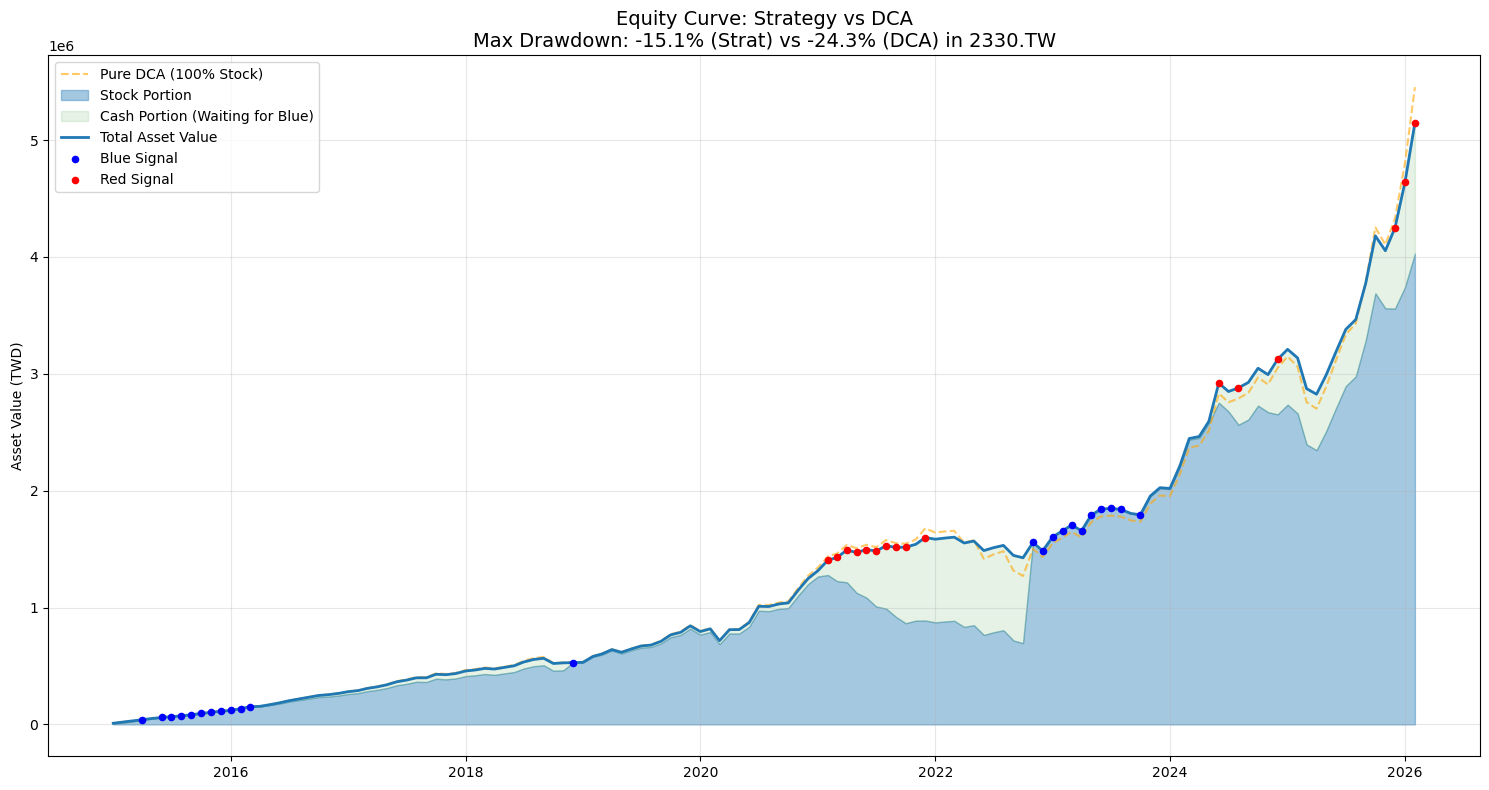

In [13]:
result_df = run_custom_strategy(df, my_config, monthly_budget)
final_df = df.copy()
final_df['DCA_Shares'] = monthly_budget / final_df['Close']
final_df['DCA_Value'] = final_df['DCA_Shares'].cumsum() * final_df['Close']


# 1. 強制對齊日期 (確保 result_df 繼承 final_df 的正確時間戳)
r = result_df.copy()
d = final_df.copy()

r = standardize_date(result_df)
d = standardize_date(final_df)

perf_matrix = get_performance_v2(r, d, monthly_budget)

# 美化輸出
def fmt_metric(name, x):
    if isinstance(x, (int, float, np.floating)):
        # ratio 類不要乘 100
        if "Sharpe" in name or "Sortino" in name or "Calmar" in name or "倍數 MOIC" in name:
            return f"{x:,.2f}"
        # 百分比類才乘 100
        if "年化" in name or "MDD" in name or "CAGR" in name or "XIRR" in name or "TWRR" in name:
            return f"{x*100:,.2f}%"
        return f"{x:,.2f}"
    return str(x)

print(f'config={my_config}, target={target}, first_year = {r['Date'][0]}')
display(perf_matrix.apply(lambda col: [fmt_metric(idx, v) for idx, v in col.items()], axis=0))

# 4. 視覺化：堆疊組成圖
plt.figure(figsize=(15, 8))

# 畫出基準線
plt.plot(d['Date'], d['DCA_Value'], label='Pure DCA (100% Stock)', color='orange', linestyle='--', alpha=0.6)

# 畫出策略組成 (用堆疊圖看 90% 現金)
plt.fill_between(r['Date'], 0, r['Shares_Value'], label='Stock Portion', color='#1f77b4', alpha=0.4)
plt.fill_between(r['Date'], r['Shares_Value'], r['Total_Value'], label='Cash Portion (Waiting for Blue)', color='green', alpha=0.1)
plt.plot(r['Date'], r['Total_Value'], label='Total Asset Value', color='#1f77b4', linewidth=2)

# 標註藍燈區域
if 'Light' in r.columns:
    blue_days = r[r['Light'] == '藍']['Date']
    plt.scatter(blue_days, r.loc[r['Light'] == '藍', 'Total_Value'], color='blue', s=20, label='Blue Signal', zorder=5)

if 'Light' in r.columns:
    red_days = r[r['Light'] == '紅']['Date']
    plt.scatter(red_days, r.loc[r['Light'] == '紅', 'Total_Value'], color='red', s=20, label='Red Signal', zorder=5)

mdd_s = float(perf_matrix.loc["最大回撤 MDD", "戰術策略"])
mdd_d = float(perf_matrix.loc["最大回撤 MDD", "純定期定額 DCA"])

plt.title(f"Equity Curve: Strategy vs DCA\nMax Drawdown: {mdd_s:.1%} (Strat) vs {mdd_d:.1%} (DCA) in {target}", fontsize=14)
plt.ylabel("Asset Value (TWD)")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

🔍 進入 Debug 模式：讀取本地檔案 'ndc_1984.xls'...
📊 [Debug] 原始資料前 15 列預覽：
          0           1          2
0       NaN  景氣對策信號(燈號)  景氣對策信號(分)
1       NaN        原始數值       原始數值
2   1984-01         NaN         42
3   1984-02         NaN         39
4   1984-03         NaN         37
5   1984-04         NaN         34
6   1984-05         NaN         37
7   1984-06         NaN         30
8   1984-07         NaN         30
9   1984-08         NaN         27
10  1984-09         NaN         25
11  1984-10         NaN         28
12  1984-11         NaN         21
13  1984-12         NaN         21
14  1985-01         NaN         16
✅ 本地 Excel 解析成功！
正在獲取 0050.TW 歷史報價並合併資料...
🔍 進入 Debug 模式：讀取本地檔案 'ndc_1984.xls'...
📊 [Debug] 原始資料前 15 列預覽：
          0           1          2
0       NaN  景氣對策信號(燈號)  景氣對策信號(分)
1       NaN        原始數值       原始數值
2   1984-01         NaN         42
3   1984-02         NaN         39
4   1984-03         NaN         37
5   1984-04         NaN         34
6   1984-05         NaN   

,戰術策略,純定期定額 DCA
總投入（每月加碼）,"1,340,000.00","1,340,000.00"
最終淨值,"5,147,788.66","5,451,899.20"
獲利,"3,807,788.66","4,111,899.20"
倍數 MOIC,3.84,4.07
XIRR（年化，現金流）,22.75%,23.68%
TWRR年化（策略能力）,18.08%,18.84%
年化波動（flow-adjusted）,15.64%,18.02%
Sharpe（flow-adjusted）,1.15,1.05
Sortino（flow-adjusted）,1.88,1.65
最大回撤 MDD,-15.06%,-24.26%


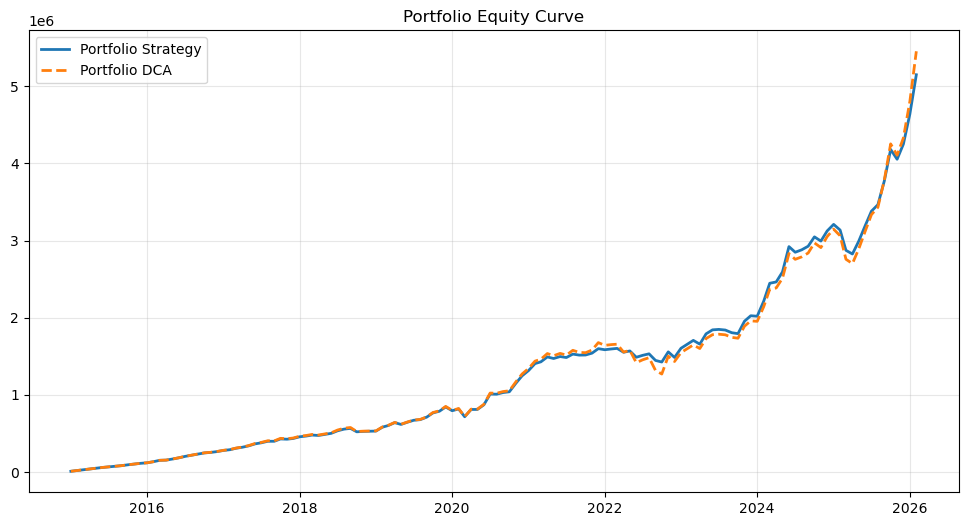

In [ ]:
# target ='0050.TW'
# target ='00631L.TW'
# target ='2330.TW'
# target ='00697B.TWO'

target ='0050.TW'
raw_data = fetch_data_robust(start_year=2015, file_path='ndc_1984.xls', target = target)
    
if raw_data is not None:
    final_df_0050 = generate_signals(raw_data)
else:
    print(f"❌ 程式終止： data {target} 未就緒，請確保資料就緒後再重新執行。")

target ='00631L.TW'
raw_data = fetch_data_robust(start_year=2015, file_path='ndc_1984.xls', target = target)
    
if raw_data is not None:
    final_df_00631L = generate_signals(raw_data)
else:
    print(f"❌ 程式終止： data {target} 未就緒，請確保資料就緒後再重新執行。")

target ='2330.TW'
raw_data = fetch_data_robust(start_year=2015, file_path='ndc_1984.xls', target = target)
    
if raw_data is not None:
    final_df_2330 = generate_signals(raw_data)
else:
    print(f"❌ 程式終止： data {target} 未就緒，請確保資料就緒後再重新執行。")

result_df_0050 = run_custom_strategy(final_df_0050, my_config, monthly_budget)
result_df_00631l = run_custom_strategy(final_df_00631L, my_config, monthly_budget)
result_df_2330 = run_custom_strategy(final_df_2330, my_config, monthly_budget)


df_0050 = final_df_0050.copy()
df_00631L = final_df_00631L.copy()
df_2330 = final_df_2330.copy()

df_0050   = standardize_date(df_0050)
df_00631L = standardize_date(df_00631L)
df_2330   = standardize_date(df_2330)

df_0050["DCA_Shares"] = monthly_budget / df_0050["Close"]
df_0050["DCA_Value"]  = df_0050["DCA_Shares"].cumsum() * df_0050["Close"]

df_00631L["DCA_Shares"] = monthly_budget / df_00631L["Close"]
df_00631L["DCA_Value"]  = df_00631L["DCA_Shares"].cumsum() * df_00631L["Close"]

df_2330["DCA_Shares"] = monthly_budget / df_2330["Close"]
df_2330["DCA_Value"]  = df_2330["DCA_Shares"].cumsum() * df_2330["Close"]

ratios = [0.0, 0.0, 1.0]

matrix, port = get_performance_v2_portfolio(
    df_strat_list=[result_df_0050, result_df_00631l, result_df_2330],
    df_dca_list=[df_0050, df_00631L, df_2330],
    ratios=ratios,
    monthly_budget=monthly_budget,
    value_col_strat="Total_Value",
    value_col_dca="DCA_Value",
)

display(pretty_perf_matrix(matrix))
plt.figure(figsize=(12,6))
plt.plot(port["Date"], port["Value_s"], label="Portfolio Strategy", linewidth=2)
plt.plot(port["Date"], port["Value_d"], label="Portfolio DCA", linewidth=2, linestyle="--")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Portfolio Equity Curve")
plt.show()

In [7]:
print("Single DCA total contrib expected:", len(df_2330) * monthly_budget)
print("Portfolio contrib_d unique:", np.unique(port["Contrib_d"].values)[:5])
print("Portfolio contrib_s unique:", np.unique(port["Contrib_s"].values)[:10])
print("Portfolio total contrib_d:", port["Contrib_d"].sum())
print("Portfolio total contrib_s:", port["Contrib_s"].sum())
print("single len/min/max:", len(df_2330), df_2330["Date"].min(), df_2330["Date"].max())
print("port   len/min/max:", len(port), port["Date"].min(), port["Date"].max())
same_dates = df_2330["Date"].reset_index(drop=True).equals(port["Date"].reset_index(drop=True))
print("dates identical?", same_dates)
print("DCA head match?", np.allclose(df_2330["DCA_Value"].values[:5], port["Value_d"].values[:5]))
print("DCA tail match?", np.allclose(df_2330["DCA_Value"].values[-5:], port["Value_d"].values[-5:]))

print("Strat head match?", np.allclose(result_df_2330["Total_Value"].values[:5], port["Value_s"].values[:5]))
print("Strat tail match?", np.allclose(result_df_2330["Total_Value"].values[-5:], port["Value_s"].values[-5:]))

Single DCA total contrib expected: 1340000
Portfolio contrib_d unique: [10000.]
Portfolio contrib_s unique: [10000.]
Portfolio total contrib_d: 1340000.0
Portfolio total contrib_s: 1340000.0
single len/min/max: 134 2015-01-01 00:00:00 2026-02-01 00:00:00
port   len/min/max: 134 2015-01-01 00:00:00 2026-02-01 00:00:00
dates identical? True
DCA head match? True
DCA tail match? True
Strat head match? True
Strat tail match? True
